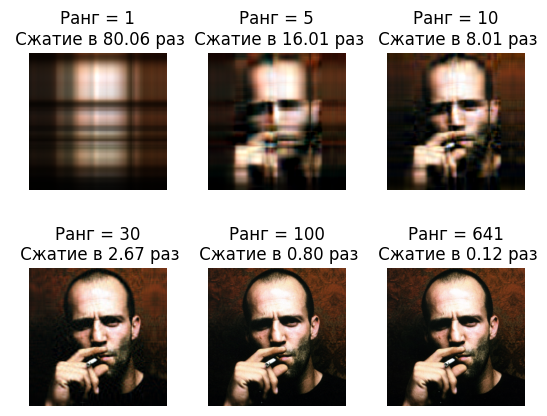

✅ Все автоматические проверки пройдены. Задание выполнено корректно!


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error

img = Image.open('/content/stathem.jpg')
img = img.convert('RGB')
img_array = np.array(img)
h, w, c = img_array.shape

#переменные для блока проверки
original_shape = img_array.shape
original_flat = img_array.astype(np.float64).flatten()

R = img_array[:, :, 0].astype(np.float64)
G = img_array[:, :, 1].astype(np.float64)
B = img_array[:, :, 2].astype(np.float64)

Ur, sr, Vtr = np.linalg.svd(R, full_matrices=False)
Ug, sg, Vtg = np.linalg.svd(G, full_matrices=False)
Ub, sb, Vtb = np.linalg.svd(B, full_matrices=False)

list_of_ranks = [1, 5, 10, 30, 100, min(h, w)]
approximations = []

for r in list_of_ranks:
    R_rec = (Ur[:, :r] * sr[:r]) @ Vtr[:r, :]
    G_rec = (Ug[:, :r] * sg[:r]) @ Vtg[:r, :]
    B_rec = (Ub[:, :r] * sb[:r]) @ Vtb[:r, :]

    reconstructed = np.stack([R_rec, G_rec, B_rec], axis=2)
    reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)
    approximations.append(reconstructed)
## Применение SVD к матрице каждого канала и воссстаногвление через сингулярные числа
#вывод итогов
for i, r in enumerate(list_of_ranks):
    plt.subplot(2, 3, i + 1)
    plt.imshow(approximations[i])
    plt.axis('off')
    # Часть Г: подсчет коэффициента сжатия
    original_size = 3 * h * w
    compressed_size = 3 * r * (h + 1 + w) * 4
    compression_ratio = original_size / compressed_size
    plt.title(f'Ранг = {r}\n Сжатие в {compression_ratio:.2f} раз')

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()




# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

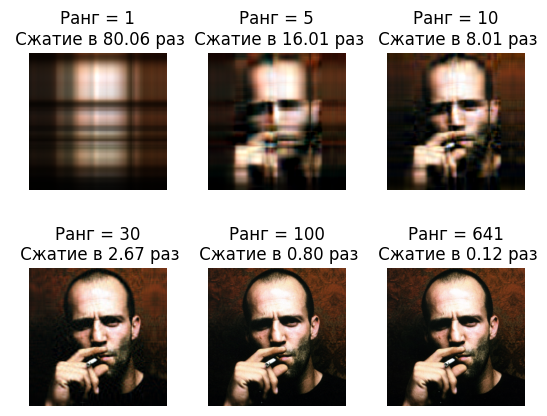

# Выводы
# В результате данной работы я научился применять алгоритм SVD для сжатия изображения с контролируемой потерей качества. Понял, как влияет ранг аппроксимации на изображение
'''
 1. При каком ранге визуальное качество перестает отличаться от оригинала? - При ранге 30-50 качество становится неотличимым
 2. Для какого ранга достигается сжатие в 10 раз? - При ранге 10
 3. Почему для темных/светлых участков ошибка разная? - Потому что темные участки содержат меньшее количество деталей, поэтому и ошибка меньше